# 03 · Calidad de datos World Bank WDI (bronze)

- **Rol:** solo contraste y comparación internacional; no es maestra de ningún indicador.
- **Variables:** 10 indicadores WDI × 9 áreas (KOR, JPN, USA, DEU, ITA, ESP, FRA, CHN, OED), 2000-2025.
- **Archivos:** `data/bronze/worldbank/<fecha más reciente>/<indicador>.json` (respuesta de la API v2 más los metadatos de extracción).
Metas del documento: completitud ≥ 95 % nacional, sin duplicados y valores dentro de rango.

In [1]:
import sys; from pathlib import Path; sys.path.insert(0, str(Path.cwd().parent))
import json
import pandas as pd
import matplotlib.pyplot as plt
from src.transform import lectura_bronze as lb
from src.quality import perfilamiento as pf
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)

ANIOS = range(2000, 2026)
PAISES = ["KOR", "JPN", "USA", "DEU", "ITA", "ESP", "FRA", "CHN", "OED"]
wb = lb.worldbank()
archivos = lb.archivos_recientes("worldbank", "*.json")
print("Carpetas bronze:", sorted({a.parent.name for a in archivos.values()}), "| filas:", len(wb), "| indicadores:", wb.indicador.nunique(), "| áreas:", wb.iso3.nunique())

# Metadatos de página de la API (lectura local: lectura_bronze no los expone)
meta = {}
for nombre, f in archivos.items():
    pag, obs = lb.crudo_json(f)
    meta[nombre] = {"lastupdated": pag["lastupdated"], "total_api": pag["total"],
                    "obs_status_no_vacio": sum(bool(o["obs_status"]) for o in obs)}
pd.DataFrame(meta).T

Carpetas bronze: ['2026-10-01'] | filas: 2340 | indicadores: 10 | áreas: 9


,lastupdated,total_api,obs_status_no_vacio
SL.GDP.PCAP.EM.KD,2026-07-13,234,0
SL.TLF.CACT.ZS,2026-07-13,234,0
SP.DYN.CBRT.IN,2026-07-13,234,0
SP.DYN.TFRT.IN,2026-07-13,234,0
SP.POP.0014.TO,2026-07-13,234,0
SP.POP.1564.TO,2026-07-13,234,0
SP.POP.65UP.TO.ZS,2026-07-13,234,0
SP.POP.65UP.TO,2026-07-13,234,0
SP.POP.DPND.OL,2026-07-13,234,0
SP.POP.TOTL,2026-07-13,234,0


## 1. Completitud indicador × país (2000-2025)

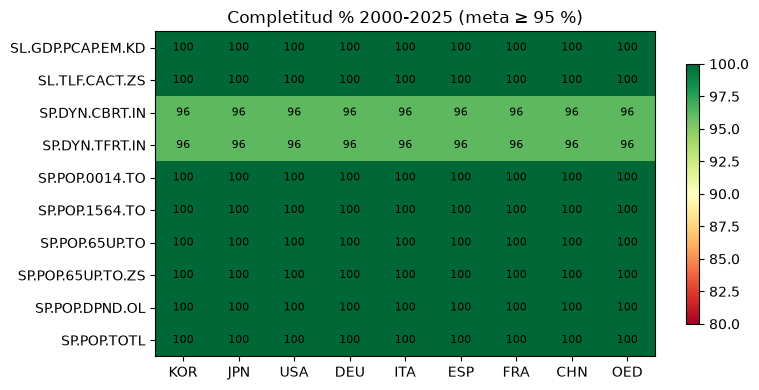

Celdas vacías: {('SP.DYN.CBRT.IN', 2025): ['CHN', 'DEU', 'ESP', 'FRA', 'ITA', 'JPN', 'KOR', 'OED', 'USA'], ('SP.DYN.TFRT.IN', 2025): ['CHN', 'DEU', 'ESP', 'FRA', 'ITA', 'JPN', 'KOR', 'OED', 'USA']}


In [2]:
comp = pf.completitud(wb, ["indicador", "iso3"], ANIOS).reset_index()
heat = comp.pivot(index="indicador", columns="iso3", values="completitud_pct")[PAISES]

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(heat.values, cmap="RdYlGn", vmin=80, vmax=100, aspect="auto")
ax.set_xticks(range(len(PAISES)), PAISES); ax.set_yticks(range(len(heat)), heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.iat[i, j]:.0f}", ha="center", va="center", fontsize=8)
ax.set_title("Completitud % 2000-2025 (meta ≥ 95 %)"); fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

faltantes = wb[wb.anio.isin(ANIOS) & wb.valor.isna()]
print("Celdas vacías:", faltantes.groupby(["indicador", "anio"]).iso3.apply(list).to_dict())

## 2. Validez: rangos
TFR 0-10; porcentajes 0-100; tasa bruta de natalidad 0-60 por mil; poblaciones y PIB por ocupado > 0.

In [3]:
RANGOS = {"SP.DYN.TFRT.IN": (0, 10), "SP.POP.65UP.TO.ZS": (0, 100), "SL.TLF.CACT.ZS": (0, 100),
          "SP.DYN.CBRT.IN": (0, 60), "SP.POP.DPND.OL": (0, 100), "SP.POP.TOTL": (1, None),
          "SP.POP.0014.TO": (1, None), "SP.POP.1564.TO": (1, None), "SP.POP.65UP.TO": (1, None),
          "SL.GDP.PCAP.EM.KD": (1, None)}
val = pd.DataFrame({ind: {"rango": f"{lo}-{hi if hi else '∞'}", "fuera_rango": len(pf.fuera_de_rango(g, lo, hi)),
                          "min": g.valor.min(), "max": g.valor.max(),
                          "KOR_ultimo": g[(g.iso3 == "KOR") & g.valor.notna()].sort_values("anio").valor.iloc[-1]}
                    for ind, g in wb.groupby("indicador") for lo, hi in [RANGOS[ind]]}).T
val

,rango,fuera_rango,min,max,KOR_ultimo
SL.GDP.PCAP.EM.KD,1-∞,0,7507.665314,156983.220017,99045.998772
SL.TLF.CACT.ZS,0-100,0,47.818,74.19,64.351
SP.DYN.CBRT.IN,0-60,0,4.5,14.57,4.7
SP.DYN.TFRT.IN,0-10,0,0.721,2.12,0.748
SP.POP.0014.TO,1-∞,0,5274134.0,309904806.0,5274134.0
SP.POP.1564.TO,1-∞,0,27844278.0,988372117.0,35902741.0
SP.POP.65UP.TO,1-∞,0,3333369.0,266766295.0,10507688.0
SP.POP.65UP.TO.ZS,0-100,0,7.017476,29.994097,20.330419
SP.POP.DPND.OL,0-100,0,9.858423,51.038573,29.267091
SP.POP.TOTL,1-∞,0,40567864.0,1412360000.0,51684564.0


## 3. Unicidad

In [4]:
CLAVE = ["indicador", "iso3", "anio"]
print("Duplicados sobre (indicador, iso3, anio):", pf.duplicados(wb, CLAVE))
print("Filas esperadas 10 × 9 × 26 =", 10 * 9 * 26, "| filas leídas:", len(wb))

Duplicados sobre (indicador, iso3, anio): 0
Filas esperadas 10 × 9 × 26 = 2340 | filas leídas: 2340


## 4. Consistencia interna
- `SP.POP.0014.TO + SP.POP.1564.TO + SP.POP.65UP.TO ≈ SP.POP.TOTL` (tolerancia 0.5 %, `config.yaml`).
- `SP.POP.65UP.TO / SP.POP.TOTL × 100 ≈ SP.POP.65UP.TO.ZS` y `SP.POP.65UP.TO / SP.POP.1564.TO × 100 ≈ SP.POP.DPND.OL`.

In [5]:
w = wb.pivot_table(index=["iso3", "anio"], columns="indicador", values="valor")
d_suma = pf.dif_pct(w["SP.POP.TOTL"], w["SP.POP.0014.TO"] + w["SP.POP.1564.TO"] + w["SP.POP.65UP.TO"])
d_65 = w["SP.POP.65UP.TO"] / w["SP.POP.TOTL"] * 100 - w["SP.POP.65UP.TO.ZS"]
d_dep = w["SP.POP.65UP.TO"] / w["SP.POP.1564.TO"] * 100 - w["SP.POP.DPND.OL"]
cons = pd.DataFrame({"suma_edades_vs_total_%": d_suma.abs().groupby("iso3").max(),
                     "pct65_calc_vs_publicado_pp": d_65.abs().groupby("iso3").max(),
                     "dep_calc_vs_publicada_pp": d_dep.abs().groupby("iso3").max()})
print("Pares fuera de tolerancia 0.5 % (suma de edades):", int((d_suma.abs() > 0.5).sum()), "de", d_suma.notna().sum())
cons.map(lambda x: f"{x:.1e}")

Pares fuera de tolerancia 0.5 % (suma de edades): 0 de 234


,suma_edades_vs_total_%,pct65_calc_vs_publicado_pp,dep_calc_vs_publicada_pp
iso3,,,
CHN,7.7e-08,3.7e-08,4.6e-14
DEU,1.2e-06,6.1e-07,4.6e-14
ESP,2.3e-06,1.1e-06,4.6e-14
FRA,1.5e-06,7.1e-07,4.6e-14
ITA,1.8e-06,7.9e-07,4.3e-14
JPN,7.9e-07,3.9e-07,5.0e-14
KOR,2.1e-06,8.8e-07,5.0e-14
OED,5.1e-07,3.9e-07,4.6e-14
USA,3.5e-07,1.6e-07,4.6e-14


## 5. Actualidad: último año con dato (rezago de publicación)

In [6]:
ult = wb[wb.valor.notna()].groupby(["indicador", "iso3"]).anio.max().unstack()[PAISES]
ult["rezago_KOR_vs_2025"] = 2025 - ult["KOR"]
ult["lastupdated"] = pd.Series({k: v["lastupdated"] for k, v in meta.items()})
ult

iso3,KOR,JPN,USA,DEU,ITA,ESP,FRA,CHN,OED,rezago_KOR_vs_2025,lastupdated
indicador,,,,,,,,,,,
SL.GDP.PCAP.EM.KD,2025,2025,2025,2025,2025,2025,2025,2025,2025,0,2026-07-13
SL.TLF.CACT.ZS,2025,2025,2025,2025,2025,2025,2025,2025,2025,0,2026-07-13
SP.DYN.CBRT.IN,2024,2024,2024,2024,2024,2024,2024,2024,2024,1,2026-07-13
SP.DYN.TFRT.IN,2024,2024,2024,2024,2024,2024,2024,2024,2024,1,2026-07-13
SP.POP.0014.TO,2025,2025,2025,2025,2025,2025,2025,2025,2025,0,2026-07-13
SP.POP.1564.TO,2025,2025,2025,2025,2025,2025,2025,2025,2025,0,2026-07-13
SP.POP.65UP.TO,2025,2025,2025,2025,2025,2025,2025,2025,2025,0,2026-07-13
SP.POP.65UP.TO.ZS,2025,2025,2025,2025,2025,2025,2025,2025,2025,0,2026-07-13
SP.POP.DPND.OL,2025,2025,2025,2025,2025,2025,2025,2025,2025,0,2026-07-13


**Cobertura geográfica.** `OED` no es un país: es el agregado "OECD members" del World Bank (promedio ponderado de los miembros), así que no tiene equivalente en KOSIS ni en los mapeos si-do. Se guarda en `dim_territorio` como `agregado_int`. `CHN` se incluye solo como referencia asiática: no es miembro de la OCDE y no entra en el escenario C (convergencia OCDE).

## 6. Resumen de calidad (Corea, nacional)

In [7]:
NOTAS = {  # consistencia / observación conceptual por indicador
    "SP.DYN.TFRT.IN":    ("sin relación interna verificable", None),
    "SP.DYN.CBRT.IN":    ("tasa por 1000: nacimientos = tasa × SP.POP.TOTL / 1000", "Observación"),
    "SP.POP.TOTL":       (f"= suma de 3 grupos (dif ≤{d_suma.abs().max():.0e} %)", None),
    "SP.POP.0014.TO":    ("suma de grupos = total", None),
    "SP.POP.1564.TO":    ("suma de grupos = total", None),
    "SP.POP.65UP.TO":    ("suma de grupos = total", None),
    "SP.POP.65UP.TO.ZS": (f"= 65+/total (dif ≤{d_65.abs().max():.0e} p.p.)", None),
    "SP.POP.DPND.OL":    (f"= 65+/15-64 (dif ≤{d_dep.abs().max():.0e} p.p.)", None),
    "SL.TLF.CACT.ZS":    ("estimación modelada OIT (15+), no es la EAPS", "Observación"),
    "SL.GDP.PCAP.EM.KD": ("PIB por ocupado, no por hora (≠ PIB_HORA)", "Observación"),
}
filas = []
for ind, g in wb[wb.iso3 == "KOR"].groupby("indicador"):
    gv = g[g.valor.notna()]
    compl = pf.completitud(g, ["iso3"], ANIOS).completitud_pct.iloc[0]
    fr, dup = len(pf.fuera_de_rango(g, *RANGOS[ind])), pf.duplicados(g, CLAVE)
    nota, estado = NOTAS[ind]
    base = "Bloqueante" if compl == 0 else ("Observación" if compl < 95 or fr or dup else "OK")
    filas.append({"variable": ind, "rol": "contraste", "periodo_KOR": f"{gv.anio.min()}-{gv.anio.max()}",
                  "completitud_KOR_%": compl, "fuera_rango": fr, "duplicados": dup,
                  "consistencia": nota, "estado": estado or base})
resumen = pd.DataFrame(filas)
resumen

,variable,rol,periodo_KOR,completitud_KOR_%,fuera_rango,duplicados,consistencia,estado
0,SL.GDP.PCAP.EM.KD,contraste,2000-2025,100.0,0,0,"PIB por ocupado, no por hora (≠ PIB_HORA)",Observación
1,SL.TLF.CACT.ZS,contraste,2000-2025,100.0,0,0,"estimación modelada OIT (15+), no es la EAPS",Observación
2,SP.DYN.CBRT.IN,contraste,2000-2024,96.2,0,0,tasa por 1000: nacimientos = tasa × SP.POP.TOT...,Observación
3,SP.DYN.TFRT.IN,contraste,2000-2024,96.2,0,0,sin relación interna verificable,OK
4,SP.POP.0014.TO,contraste,2000-2025,100.0,0,0,suma de grupos = total,OK
5,SP.POP.1564.TO,contraste,2000-2025,100.0,0,0,suma de grupos = total,OK
6,SP.POP.65UP.TO,contraste,2000-2025,100.0,0,0,suma de grupos = total,OK
7,SP.POP.65UP.TO.ZS,contraste,2000-2025,100.0,0,0,= 65+/total (dif ≤1e-06 p.p.),OK
8,SP.POP.DPND.OL,contraste,2000-2025,100.0,0,0,= 65+/15-64 (dif ≤5e-14 p.p.),OK
9,SP.POP.TOTL,contraste,2000-2025,100.0,0,0,= suma de 3 grupos (dif ≤2e-06 %),OK


## 7. Hallazgos y acciones para silver

**Hallazgos**
- **Estructura completa:** 2 340 filas = 10 indicadores × 9 áreas × 26 años, 0 duplicados en `(indicador, iso3, anio)` y 0 valores fuera de rango.
- **Completitud:** 8 de 10 indicadores al 100 % en las 9 áreas. `SP.DYN.TFRT.IN` y `SP.DYN.CBRT.IN` llegan al 96.2 % porque 2025 todavía no está publicado para ningún país. Las 18 celdas vacías vienen como `value = null`, y todo cumple la meta ≥ 95 %.
- **Actualidad:** versión WDI `lastupdated = 2026-07-13`. Población, participación y PIB por ocupado llegan a 2025; fecundidad y natalidad tienen 1 año de rezago (2024).
- **Coherencia interna exacta:** 0-14 + 15-64 + 65+ = total (dif ≤ 2e-06 %), y el % de 65+ y la dependencia publicados coinciden con los recalculados. Esto muestra que salen de la misma base de población, no que haya validación independiente. `SP.POP.DPND.OL` usa 65+/15-64, la misma definición que el proyecto (a diferencia de la OCDE, 20-64), así que es el contraste directo de `DEPENDENCIA_VEJEZ`.
- `obs_status` está vacío en el 100 % de los registros: WB no marca estimaciones. El dato 2025 de población y el de `SL.TLF.CACT.ZS` (modelo OIT) son estimaciones, no observaciones.
- `OED` es el agregado "OECD members" del WB, no un país. `CHN` no es miembro OCDE: sirve solo como referencia regional.

**Acciones para silver**
- Mandar las 18 filas con valor nulo a `ctl.rechazos` con el motivo "valor nulo en origen (año no publicado)". Son 0.8 % de la carga, dentro del ≤ 2 %.
- Homologar con `config.yaml`: `SP.POP.*` → `POBLACION` con `grupo_edad` (`TOTAL`, `0-14`, `15-64`, `65+`), `SP.DYN.TFRT.IN` → `TFR`, `SP.POP.DPND.OL` → `DEPENDENCIA_VEJEZ`, `SP.POP.65UP.TO.ZS` → `PROP_65MAS`, `SL.TLF.CACT.ZS` → `TASA_PARTICIPACION`.
- `SP.DYN.CBRT.IN`: convertir a nacimientos con `tasa × SP.POP.TOTL / 1000` antes de conciliar con KOSIS, marcarlo como derivado y aceptar el error de redondeo de la tasa (1 decimal).
- `SL.GDP.PCAP.EM.KD` (por ocupado) y `SL.TLF.CACT.ZS` (modelada) van a `silver.conciliacion` con una nota de "concepto no idéntico". No deben contar en la meta de ±3 % sin esa aclaración.
- Guardar `version_publicacion = 2026-07-13` y `estado = 'preliminar'` para el año 2025.